# Pruebas del clasificador de Pokémon

Carga los 2 modelos entrenados y predice el Pokémon de cada imagen.
Pon las imágenes a probar en la carpeta **`test_images/`** y ejecuta todo (Run All).

In [1]:
import os, glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess

CLASS_NAMES = ["Abra", "Aerodactyl", "Alakazam", "Arbok", "Arcanine", "Articuno", "Beedrill", "Bellsprout", "Blastoise", "Bulbasaur", "Butterfree", "Caterpie", "Chansey", "Charizard", "Charmander", "Charmeleon", "Clefable", "Clefairy", "Cloyster", "Cubone", "Dewgong", "Diglett", "Ditto", "Dodrio", "Doduo", "Dragonair", "Dragonite", "Dratini", "Drowzee", "Dugtrio", "Eevee", "Ekans", "Electabuzz", "Electrode", "Exeggcute", "Exeggutor", "Farfetchd", "Fearow", "Flareon", "Gastly", "Gengar", "Geodude", "Gloom", "Golbat", "Goldeen", "Golduck", "Graveler", "Grimer", "Growlithe", "Gyarados", "Haunter", "Hitmonchan", "Hitmonlee", "Horsea", "Hypno", "Ivysaur", "Jigglypuff", "Jolteon", "Jynx", "Kabutops", "Kadabra", "Kakuna", "Kangaskhan", "Kingler", "Koffing", "Lapras", "Lickitung", "Machamp", "Machoke", "Machop", "Magikarp", "Magmar", "Magnemite", "Magneton", "Mankey", "Marowak", "Meowth", "Metapod", "Mew", "Mewtwo", "Moltres", "Mr. Mime", "MrMime", "Nidoking", "Nidoqueen", "Nidorina", "Nidorino", "Ninetales", "Oddish", "Omanyte", "Omastar", "Parasect", "Pidgeot", "Pidgeotto", "Pidgey", "Pikachu", "Pinsir", "Poliwag", "Poliwhirl", "Poliwrath", "Ponyta", "Porygon", "Primeape", "Psyduck", "Raichu", "Rapidash", "Raticate", "Rattata", "Rhydon", "Rhyhorn", "Sandshrew", "Sandslash", "Scyther", "Seadra", "Seaking", "Seel", "Shellder", "Slowbro", "Slowpoke", "Snorlax", "Spearow", "Squirtle", "Starmie", "Staryu", "Tangela", "Tauros", "Tentacool", "Tentacruel", "Vaporeon", "Venomoth", "Venonat", "Venusaur", "Victreebel", "Vileplume", "Voltorb", "Vulpix", "Wartortle", "Weedle", "Weepinbell", "Weezing", "Wigglytuff", "Zapdos", "Zubat"]

In [2]:
# Carga de los modelos
MODELOS = [
    {'nombre': 'MobileNetV2',    'model': load_model('pokemon_cnn_best.h5',    compile=False)},
    {'nombre': 'EfficientNetB0', 'model': load_model('pokemon_effnet_best.h5', compile=False)},
]
for M in MODELOS:
    M['size'] = int(M['model'].input_shape[1])
    M['prep'] = eff_preprocess if M['size'] == 224 else (lambda a: a / 255.0)

In [3]:
# Predice una imagen y muestra la tabla con el Top-3 de cada modelo
def predecir(image_path, k=3):
    img = Image.open(image_path).convert('RGB')
    tops = []
    for M in MODELOS:
        arr = M['prep'](np.array(img.resize((M['size'], M['size'])), dtype='float32'))[None, ...]
        probs = M['model'].predict(arr, verbose=0)[0]
        idx = np.argsort(probs)[-k:][::-1]
        tops.append([(CLASS_NAMES[i], probs[i]) for i in idx])

    cell_text = [[f"{tops[m][r][0]}   {tops[m][r][1]*100:.1f}%" for m in range(len(MODELOS))]
                 for r in range(k)]
    col_labels = [M['nombre'] for M in MODELOS]
    row_labels = [f'Top {r+1}' for r in range(k)]

    fig, (ax_img, ax_tab) = plt.subplots(1, 2, figsize=(9, 3.2),
                                         gridspec_kw={'width_ratios': [1, 1.5]})
    ax_img.imshow(img); ax_img.axis('off'); ax_img.set_title(os.path.basename(image_path))
    ax_tab.axis('off')
    tab = ax_tab.table(cellText=cell_text, rowLabels=row_labels, colLabels=col_labels,
                       cellLoc='center', loc='center')
    tab.auto_set_font_size(False); tab.set_fontsize(10); tab.scale(1, 1.8)
    for c in range(len(col_labels)):                 # resalta el Top 1 de cada modelo
        tab[(1, c)].set_facecolor('#d6e6f7')
    plt.tight_layout(); plt.show()

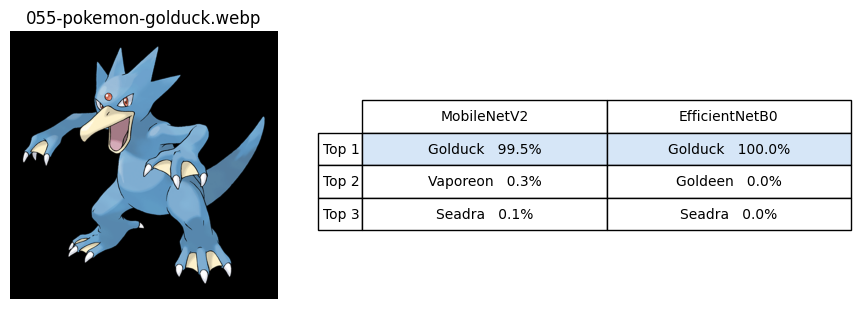

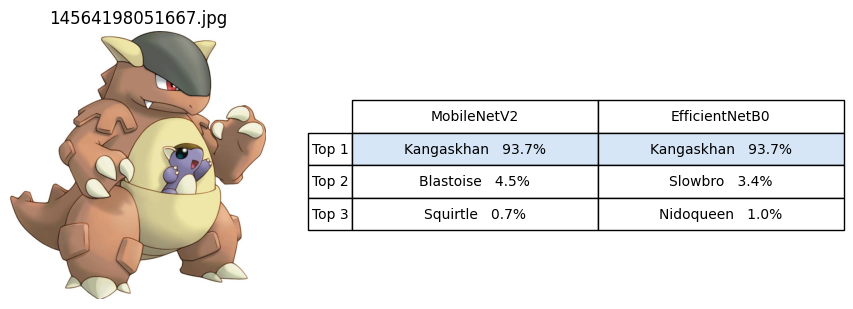

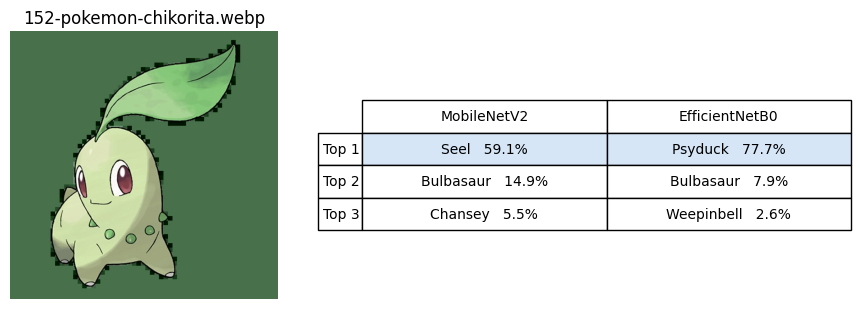

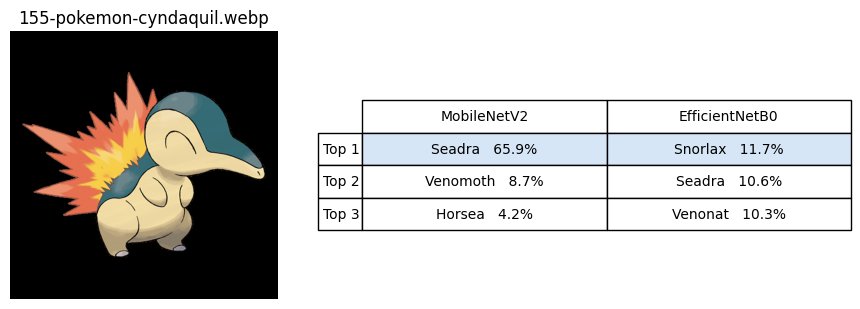

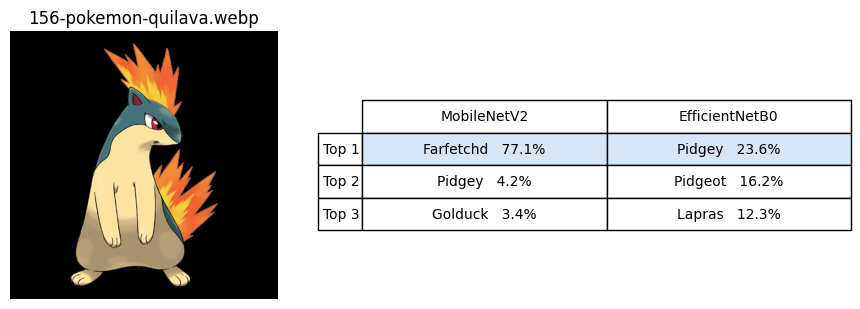

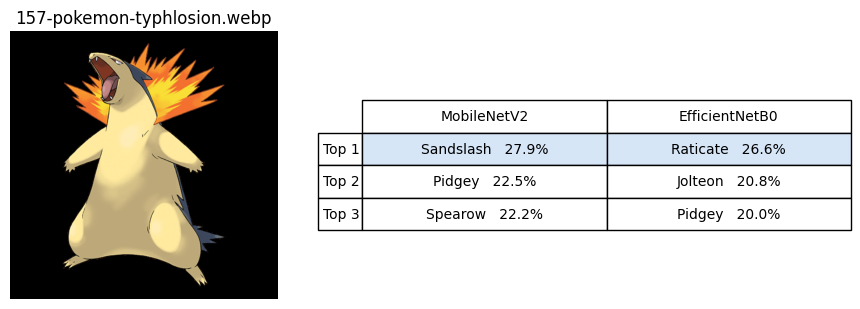

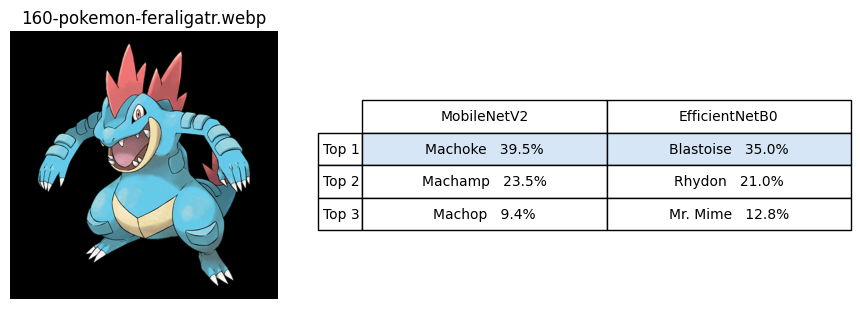

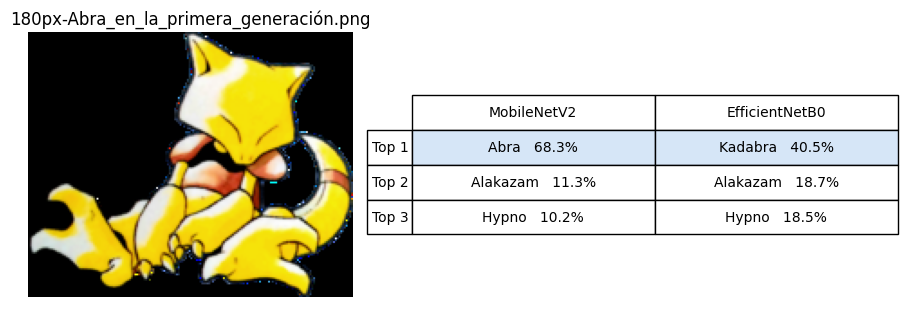

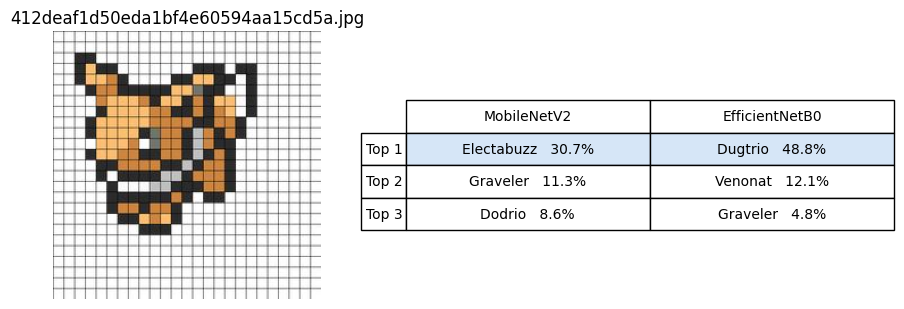

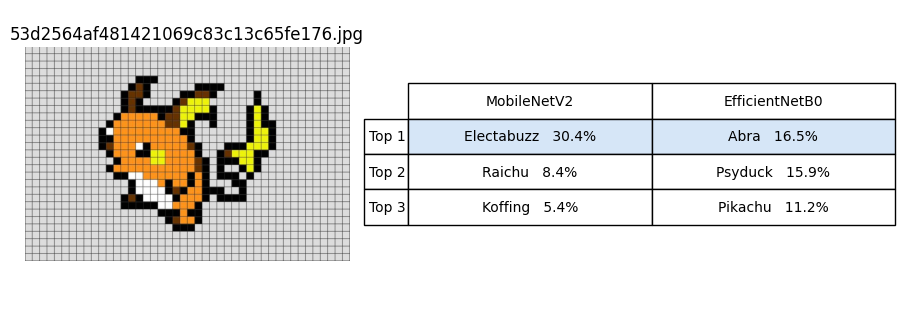

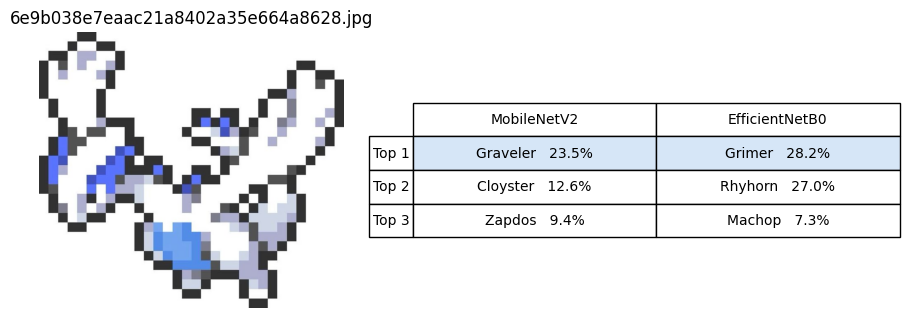

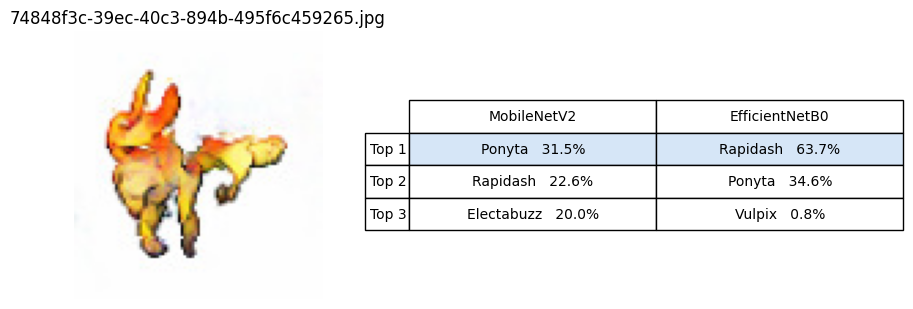

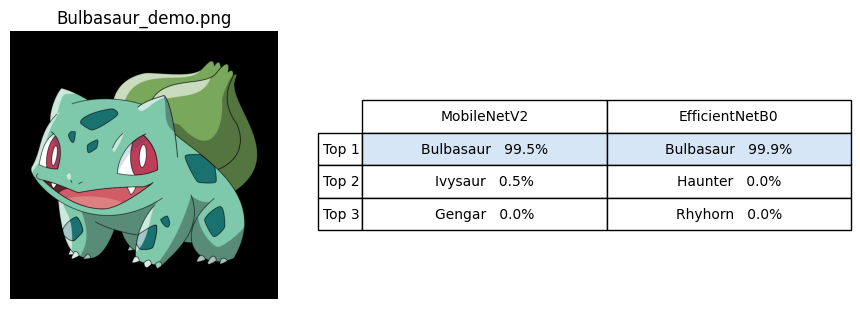

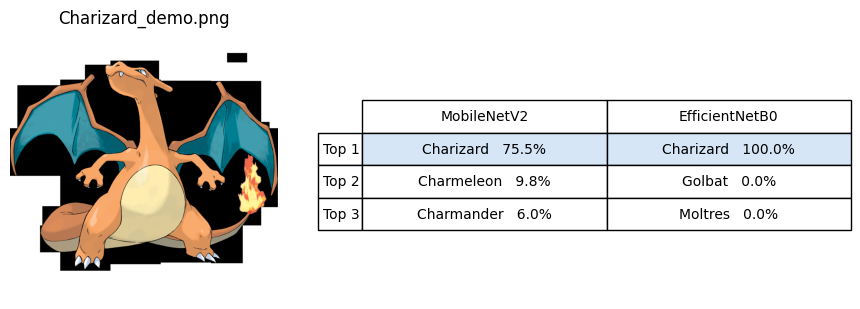

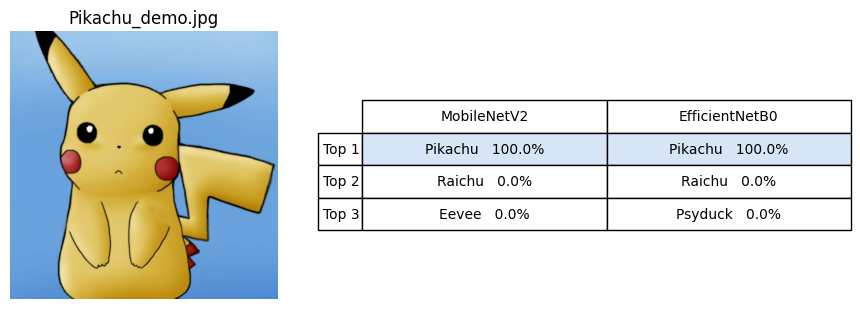

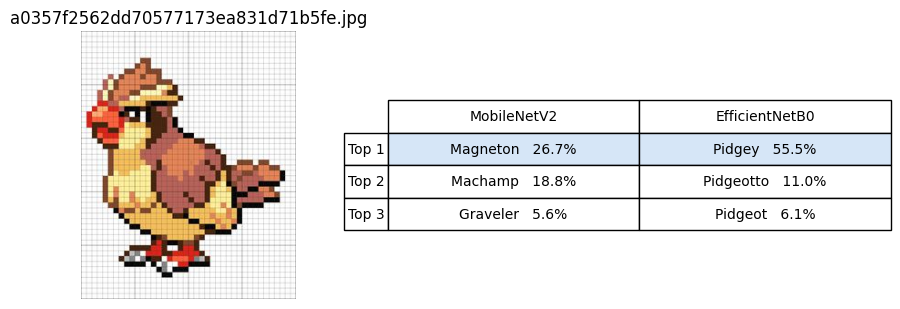

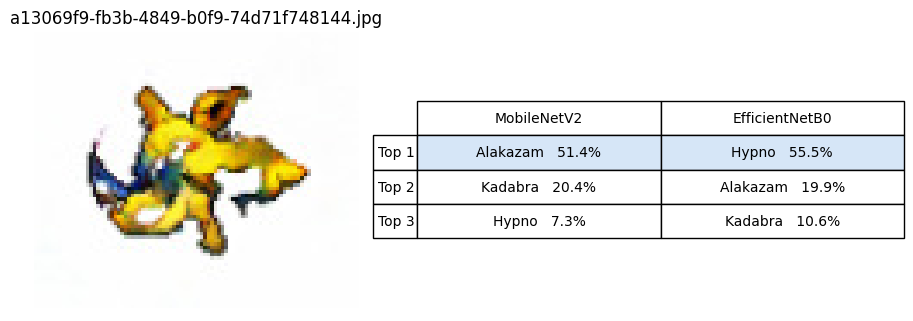

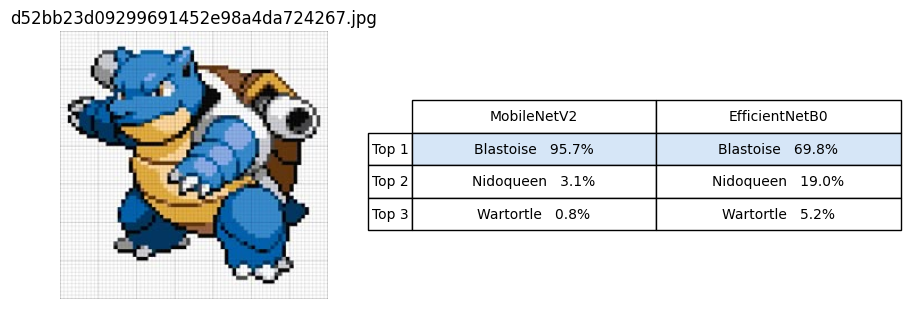

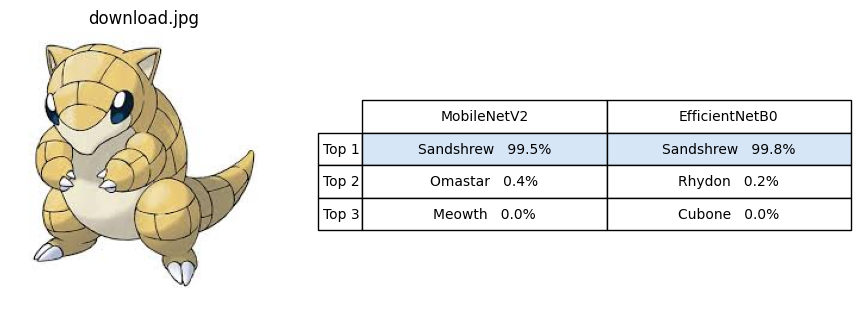

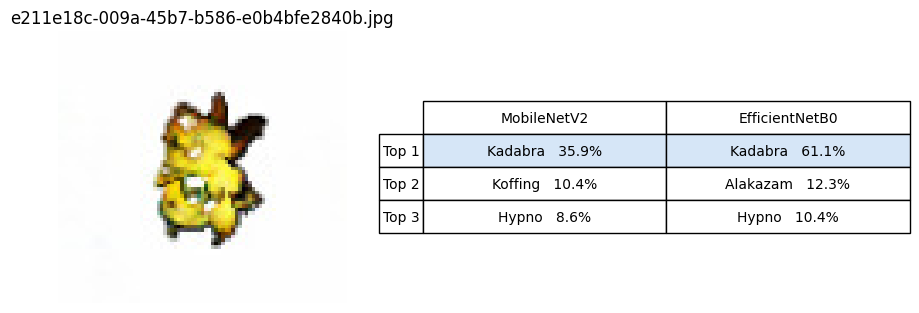

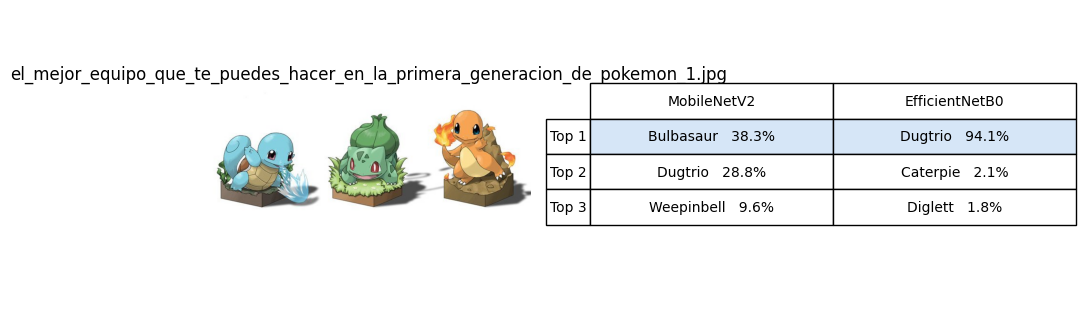

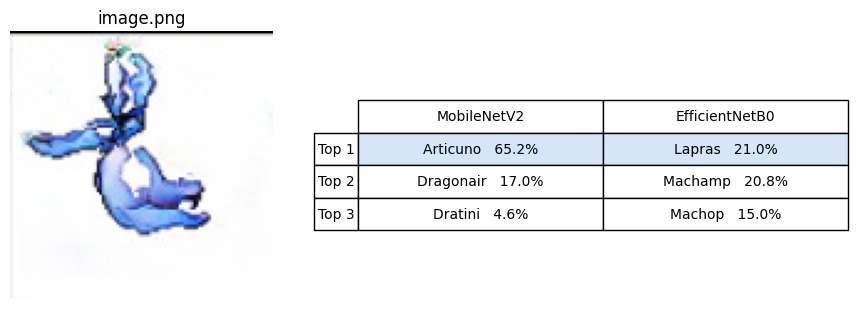

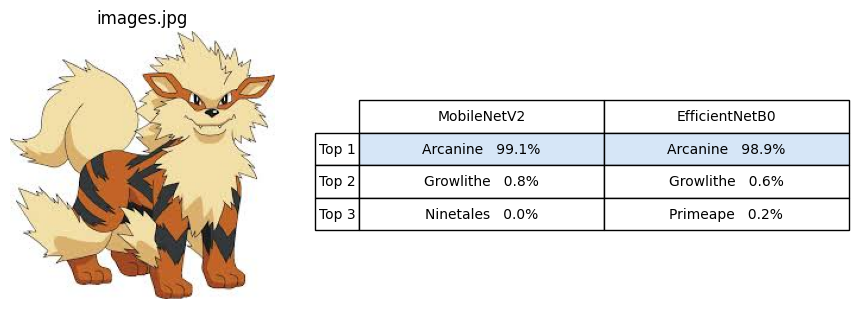

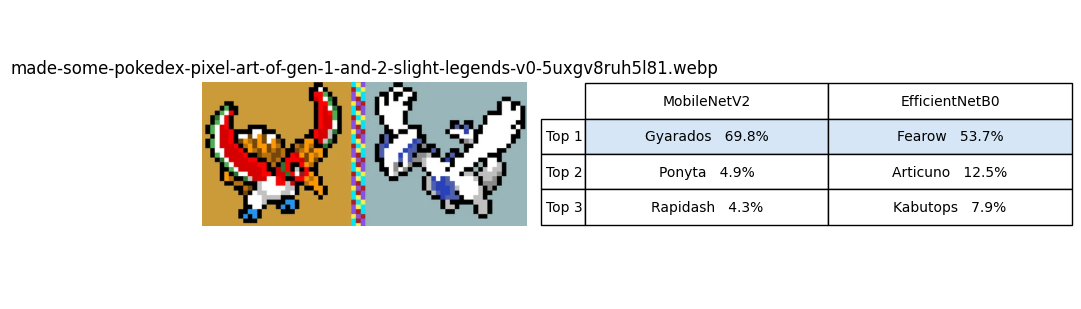

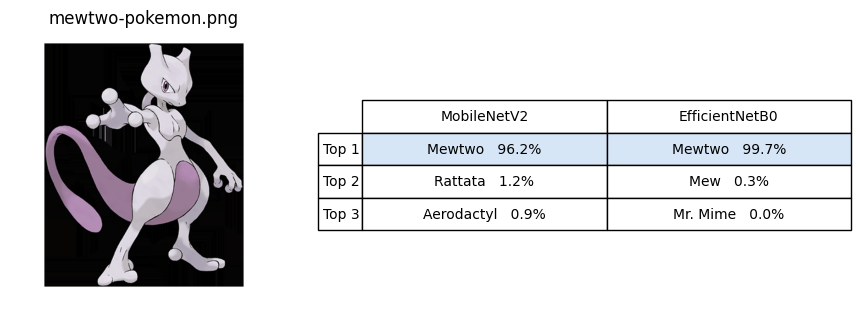

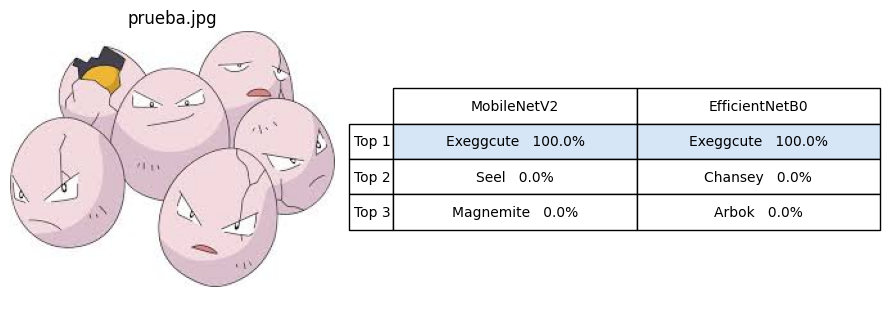

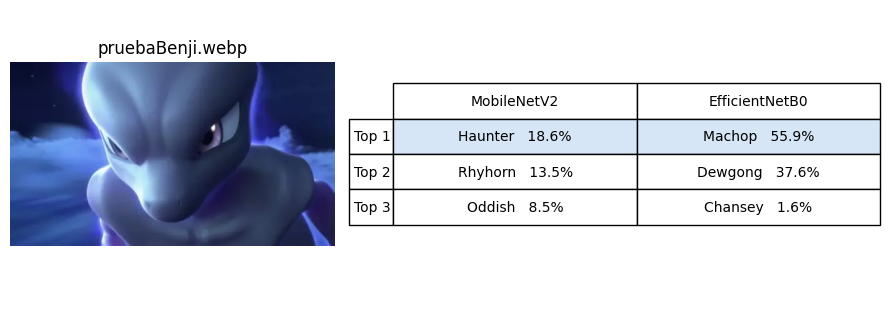

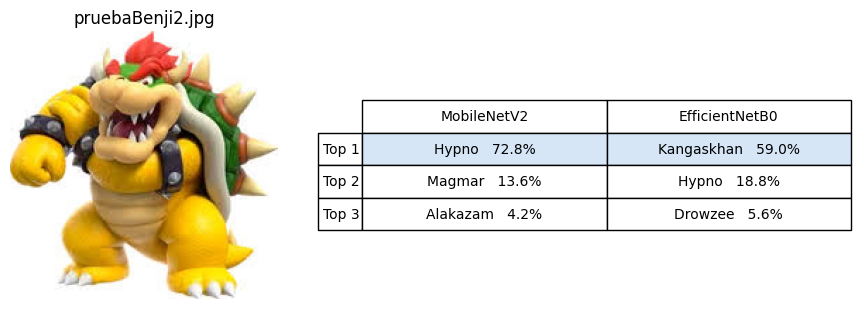

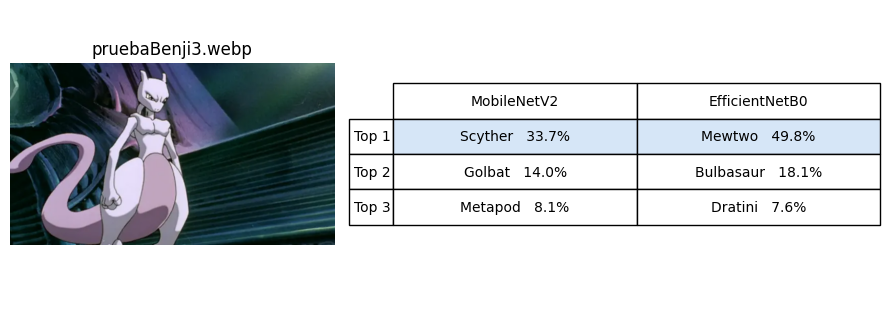

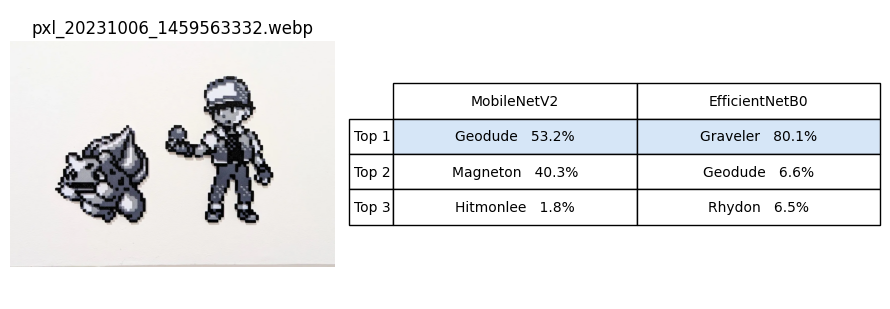

In [6]:
# Pruebas: clasifica todas las imágenes de test_images/
image_paths = sorted(sum([glob.glob(f'test_images/*.{e}')
                          for e in ('png', 'jpg', 'jpeg', 'webp')], []))
for ruta in image_paths:
    predecir(ruta)